# USGS Pesticide Data (2002)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
#read in the pesticide data for 2002
pest_data = pd.read_csv('EPest.county.estimates.2002.txt', delimiter='\t', encoding='utf-8', dtype=str)
print(pest_data.shape)
pest_data.head(100)

(337607, 6)


,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG
0,"2,4-D",2002,01,001,32.5,370.4
1,"2,4-D",2002,01,003,619.6,1901.3
2,"2,4-D",2002,01,005,610.2,671.4
3,"2,4-D",2002,01,007,507,508.9
4,"2,4-D",2002,01,009,7052.4,7141.7
...,...,...,...,...,...,...
95,"2,4-D",2002,05,027,4108.2,4108.2
96,"2,4-D",2002,05,029,5338.4,5630
97,"2,4-D",2002,05,031,13657.9,13695.1
98,"2,4-D",2002,05,033,6431.4,6591.5


In [4]:
#need to combine the STATE_FIPS_CODE and COUNTY_FIPS_CODE to get the full county FIPS for joining with other data
pest_data['FIPS'] = pest_data['STATE_FIPS_CODE'] + pest_data['COUNTY_FIPS_CODE']
pest_data.head()



,COMPOUND,YEAR,STATE_FIPS_CODE,COUNTY_FIPS_CODE,EPEST_LOW_KG,EPEST_HIGH_KG,FIPS
0,"2,4-D",2002,01,001,32.5,370.4,01001
1,"2,4-D",2002,01,003,619.6,1901.3,01003
2,"2,4-D",2002,01,005,610.2,671.4,01005
3,"2,4-D",2002,01,007,507,508.9,01007
4,"2,4-D",2002,01,009,7052.4,7141.7,01009


In [6]:
#fix KG readings to be numeric since we forced string on the read in 
pest_data['EPEST_HIGH_KG'] = pd.to_numeric(pest_data['EPEST_HIGH_KG'], errors='coerce')
#now we need to pivot so we have columns for each pesticide, and rows for each county
pest_pivot = pest_data.pivot_table(index='FIPS', columns='COMPOUND', values='EPEST_HIGH_KG').reset_index()
print(pest_pivot.head())

COMPOUND   FIPS   2,4-D  2,4-DB  6-BENZYLADENINE  ABAMECTIN  ACEPHATE  \
0         01001   370.4   678.7              NaN        NaN     124.9   
1         01003  1901.3  4534.1              NaN        NaN     496.4   
2         01005   671.4  1483.8              NaN        NaN     266.5   
3         01007   508.9   218.9              NaN        NaN       NaN   
4         01009  7141.7   230.0              0.1        NaN      51.2   

COMPOUND  ACETAMIPRID  ACETOCHLOR  ACIBENZOLAR  ACIFLUORFEN  ...  TRIFLURALIN  \
0                 NaN        97.1          NaN          0.6  ...        363.8   
1                 NaN       231.2          NaN        115.5  ...       1613.2   
2                 NaN       113.4          NaN         50.4  ...       1489.8   
3                 NaN         9.6          NaN          NaN  ...          0.3   
4                 NaN        84.3          NaN          2.4  ...        185.7   

COMPOUND  TRIFLUSULFURON  TRIFORINE  TRINEXAPAC  VINCLOZOLIN  \
0         

In [9]:
#now how many NaNs are we dealing with?
print(pest_pivot.isna().sum())
#print all the column names
for col in pest_pivot.columns:
    print(col)


COMPOUND
FIPS                    0
2,4-D                   4
2,4-DB                396
6-BENZYLADENINE      2488
ABAMECTIN            2552
                     ... 
ZETA-CYPERMETHRIN     469
ZINC                 2608
ZINEB                3050
ZIRAM                1547
ZOXAMIDE             2881
Length: 347, dtype: int64
FIPS
2,4-D
2,4-DB
6-BENZYLADENINE
ABAMECTIN
ACEPHATE
ACETAMIPRID
ACETOCHLOR
ACIBENZOLAR
ACIFLUORFEN
ALACHLOR
ALDICARB
ALUMINUM PHOSPHIDE
AMETRYN
AMITRAZ
AMPELOMYCES QUISQUALIS
ANILAZINE
ASULAM
ATRAZINE
AVIGLYCINE
AZADIRACHTIN
AZINPHOS-METHYL
AZOXYSTROBIN
BACILLUS CEREUS
BACILLUS SUBTILIS
BACILLUS THURINGIENSIS
BENFLURALIN
BENOMYL
BENSULFURON
BENSULIDE
BENTAZONE
BIFENAZATE
BIFENTHRIN
BISPYRIBAC
BORDEAUX MIXTURE
BROMACIL
BROMOXYNIL
BUPROFEZIN
BUTRALIN
BUTYLATE
CALCIUM CHLORIDE
CALCIUM POLYSULFIDE
CAPTAN
CARBARYL
CARBOFURAN
CARBOXIN
CARFENTRAZONE-ETHYL
CHINOMETHIONAT
CHLORETHOXYFOS
CHLORFENAPYR
CHLORIDAZON
CHLORIMURON
CHLORMEQUAT
CHLOROPICRIN
CHLOROTHALONIL
CHLOROXURON
CHLO

Okay, so alot of NaNs, but it's tough to know which chemicals might be most associated with cancer rates. May need to interpolate before PCA, but literature suggests interpolating pesticide values can be tricky because some NaNs may represent states that banned certain chemicals, or lack of testing. 
Khalili et al (https://link.springer.com/article/10.1007/s10614-025-11201-x) states "When missingness is not completely random, the dataset can be partitioned into blocks based on the missing data pattern."
So it may be possible to determine what states ban what chemicals, and accurately impute those as 0s, and perhaps local averages for other areas, but that is likely are very large task. 


In [ ]:
#get rid of columns with over 80% NaN values
threshold = len(pest_pivot) * 0.8
pest_pivot = pest_pivot.dropna(thresh=threshold, axis=1)
print(pest_pivot.shape)



(3052, 40)


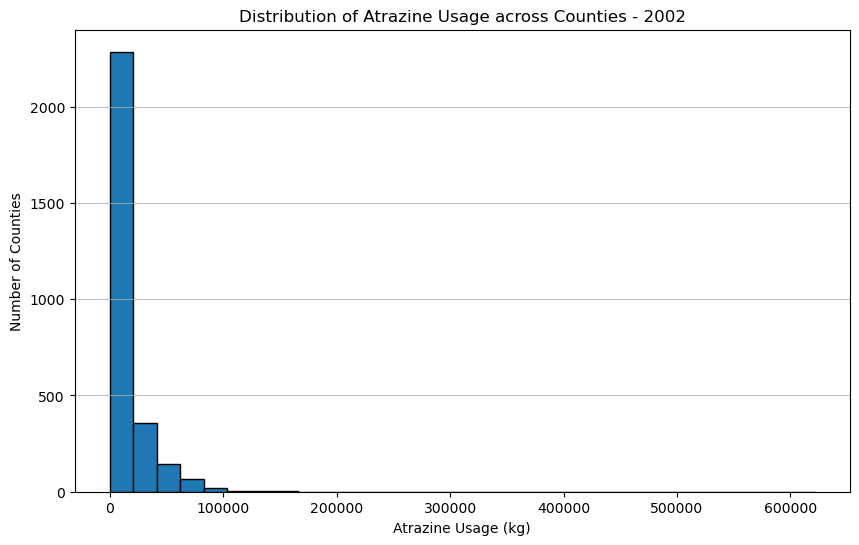

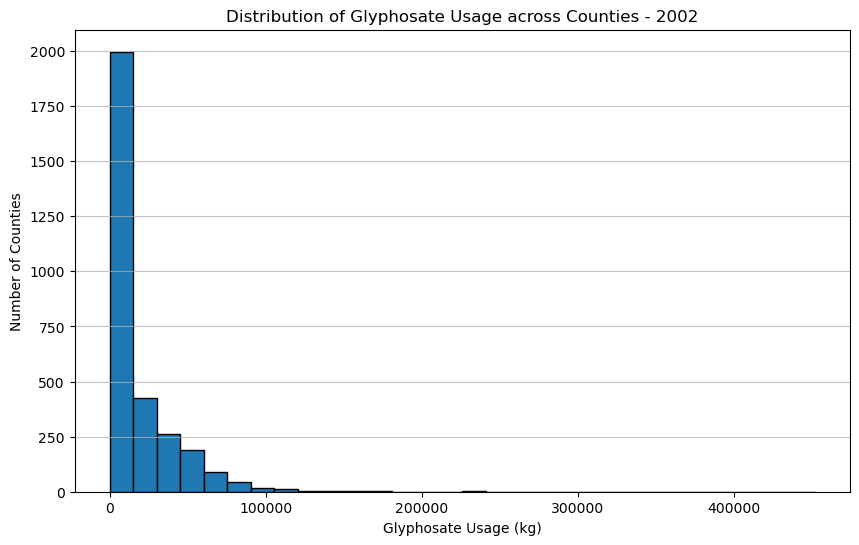

In [11]:
#distributions of a couple pesticides
plt.figure(figsize=(10,6))
plt.hist(pest_pivot['ATRAZINE'], bins=30, edgecolor='black')
plt.title('Distribution of Atrazine Usage across Counties - 2002')
plt.xlabel('Atrazine Usage (kg)')
plt.ylabel('Number of Counties')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(10,6))
plt.hist(pest_pivot['GLYPHOSATE'], bins=30, edgecolor='black')
plt.title('Distribution of Glyphosate Usage across Counties - 2002')
plt.xlabel('Glyphosate Usage (kg)')
plt.ylabel('Number of Counties')
plt.grid(axis='y', alpha=0.75)
plt.show()  



Wow these are extremely right-skewed. Might need a log-transform for any further processing like dimensionality reduction.

In [ ]:
#let's write this out to a new csv before doing any more transformations
pest_pivot.to_csv('usgs_pest_2002_pivot.csv', index=False)


In [ ]:

#new df with log transform to handle skewness (only numeric columns)
pest_log = pest_pivot[['FIPS']].join(np.log1p(pest_pivot.select_dtypes(include=[np.number])))
pest_log.head()


COMPOUND,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,PERMETHRIN,PICLORAM,PROPICONAZOLE,RIMSULFURON,SETHOXYDIM,TERBUFOS,THIFENSULFURON,TRICLOPYR,TRIFLURALIN,ZETA-CYPERMETHRIN
0,01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,...,3.668677,3.258097,3.194583,0.262364,4.473922,5.242276,0.587787,4.446174,5.899349,3.666122
1,01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,...,4.789989,3.520461,5.296315,0.405465,5.071417,7.036676,2.879198,7.496819,7.386595,5.129899
2,01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,...,2.791165,3.517498,6.233234,0.182322,3.100092,6.186209,0.530628,6.286557,7.307068,2.484907
3,01007,6.234215,5.393173,2.360854,3.597312,5.939645,NaN,NaN,NaN,2.694627,...,0.875469,3.081910,0.741937,0.095310,0.262364,1.193922,NaN,4.464758,0.262364,0.182322
4,01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,NaN,2.572612,5.027820,...,4.456670,6.939157,3.511545,0.182322,3.299534,3.218876,0.262364,4.432007,5.229503,2.091864


In [17]:
#write out the log transformed data as well
pest_log.to_csv('usgs_pest_2002_pivot_log.csv', index=False)

it remains to be seen if we can impute enough for PCA, but it would need to be standardized first, so let's do that  

scikit learn tutorials referenced-   
https://scikit-learn.org/stable/modules/preprocessing.html   
https://www.digitalocean.com/community/tutorials/standardscaler-function-in-python

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#scale the pesticide columns (not the FIPS column, or COMPOUND column))
pest_scaled = pest_log.copy()
pest_scaled.iloc[:, 1:] = scaler.fit_transform(pest_scaled.iloc[:, 1:])
pest_scaled.head()


COMPOUND,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,PERMETHRIN,PICLORAM,PROPICONAZOLE,RIMSULFURON,SETHOXYDIM,TERBUFOS,THIFENSULFURON,TRICLOPYR,TRIFLURALIN,ZETA-CYPERMETHRIN
0,01001,-0.939750,1.187305,-0.679894,-0.234853,-0.567676,-0.187678,-0.617208,-0.420367,1.107206,...,0.131323,-0.445130,0.303931,-1.078880,0.501550,0.089534,-0.955815,0.085997,0.140080,0.631630
1,01003,0.011906,2.265720,-0.349048,0.383036,0.419825,0.412358,0.398524,0.538094,0.848779,...,0.826245,-0.309185,1.479066,-0.985589,0.835586,0.952336,0.682465,1.526155,0.729413,1.591398
2,01005,-0.593950,1.631287,-0.620870,-0.444655,-0.404466,0.285321,-0.456116,-0.284130,0.291818,...,-0.412505,-0.310721,2.002922,-1.131061,-0.266504,0.543406,-0.996681,0.954810,0.697900,-0.142869
3,01007,-0.755112,0.546103,-1.534313,-1.095657,-0.732493,NaN,NaN,NaN,-1.016720,...,-1.599738,-0.536421,-1.067408,-1.187786,-1.852966,-1.857036,NaN,0.094770,-2.093622,-1.652627
4,01009,0.782666,0.574084,-0.733580,-0.299471,-0.452471,0.215598,NaN,-0.781002,0.170230,...,0.619674,1.462217,0.481153,-1.131061,-0.155004,-0.883377,-1.188481,0.079308,-0.125352,-0.400579


In [20]:
#write out the scaled data as well  
pest_scaled.to_csv('usgs_pest_2002_pivot_log_scaled.csv', index=False)
